In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)

import pandas as pd

df = dataset["train"].to_pandas()


In [ ]:
df_model = df.copy()
df_model = df_model[
    ["instruction", "category", "intent", "response"]
].copy()

df_model = df_model.rename(
    columns={
        "instruction": "customer_message"
    }
)

df_model.head()


,customer_message,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [ ]:
from sklearn.model_selection import train_test_split

unique_instructions = df_model["customer_message"].unique()

train_instructions, temp_instructions = train_test_split(
    unique_instructions,
    test_size=0.20,
    random_state=42
)

val_instructions, test_instructions = train_test_split(
    temp_instructions,
    test_size=0.50,
    random_state=42
)

train_df = df_model[
    df_model["customer_message"].isin(train_instructions)
].copy()

val_df = df_model[
    df_model["customer_message"].isin(val_instructions)
].copy()

test_df = df_model[
    df_model["customer_message"].isin(test_instructions)
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (21482, 4)
Validation: (2663, 4)
Test: (2727, 4)


In [ ]:
print(
    "Train ∩ Validation:",
    len(
        set(train_df["customer_message"])
        & set(val_df["customer_message"])
    )
)

print(
    "Train ∩ Test:",
    len(
        set(train_df["customer_message"])
        & set(test_df["customer_message"])
    )
)

print(
    "Validation ∩ Test:",
    len(
        set(val_df["customer_message"])
        & set(test_df["customer_message"])
    )
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
MODEL_NAMES = [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen/Qwen2.5-1.5B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct",
]

In [ ]:
benchmark_df = (
    test_df
    .groupby("intent", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

print(benchmark_df.shape)
print(benchmark_df["intent"].value_counts())

(270, 4)
intent
cancel_order                10
change_order                10
change_shipping_address     10
check_cancellation_fee      10
check_invoice               10
check_payment_methods       10
check_refund_policy         10
complaint                   10
contact_customer_service    10
contact_human_agent         10
create_account              10
delete_account              10
delivery_options            10
delivery_period             10
edit_account                10
get_invoice                 10
get_refund                  10
newsletter_subscription     10
payment_issue               10
place_order                 10
recover_password            10
registration_problems       10
review                      10
set_up_shipping_address     10
switch_account              10
track_order                 10
track_refund                10
Name: count, dtype: int64


In [ ]:
def build_intent_prompt(customer_message, intents):
    return f"""Classify the customer request into exactly one of the following intents:

{", ".join(intents)}

Customer request:
{customer_message}

Intent:"""

In [ ]:
intents = sorted(train_df["intent"].unique())

print(len(intents))
print(intents)

27
['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice', 'check_payment_methods', 'check_refund_policy', 'complaint', 'contact_customer_service', 'contact_human_agent', 'create_account', 'delete_account', 'delivery_options', 'delivery_period', 'edit_account', 'get_invoice', 'get_refund', 'newsletter_subscription', 'payment_issue', 'place_order', 'recover_password', 'registration_problems', 'review', 'set_up_shipping_address', 'switch_account', 'track_order', 'track_refund']


In [ ]:
sample_prompt = build_intent_prompt(
    benchmark_df.iloc[0]["customer_message"],
    intents
)

print(sample_prompt)

Classify the customer request into exactly one of the following intents:

cancel_order, change_order, change_shipping_address, check_cancellation_fee, check_invoice, check_payment_methods, check_refund_policy, complaint, contact_customer_service, contact_human_agent, create_account, delete_account, delivery_options, delivery_period, edit_account, get_invoice, get_refund, newsletter_subscription, payment_issue, place_order, recover_password, registration_problems, review, set_up_shipping_address, switch_account, track_order, track_refund

Customer request:
I bought the same item twice, cancel order {{Order Number}}

Intent:


In [ ]:
sample = benchmark_df.iloc[0]

prompt = build_intent_prompt(
    sample["customer_message"],
    intents
)

print("Customer:", sample["customer_message"])
print("True intent:", sample["intent"])
print("\nPrompt:\n", prompt)

Customer: I bought the same item twice, cancel order {{Order Number}}
True intent: cancel_order

Prompt:
 Classify the customer request into exactly one of the following intents:

cancel_order, change_order, change_shipping_address, check_cancellation_fee, check_invoice, check_payment_methods, check_refund_policy, complaint, contact_customer_service, contact_human_agent, create_account, delete_account, delivery_options, delivery_period, edit_account, get_invoice, get_refund, newsletter_subscription, payment_issue, place_order, recover_password, registration_problems, review, set_up_shipping_address, switch_account, track_order, track_refund

Customer request:
I bought the same item twice, cancel order {{Order Number}}

Intent:


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

In [ ]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False
    )

In [ ]:
generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

prediction = tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True
)

print("Predicted intent:", prediction)

Predicted intent:  cancel_order
Reason: The customer wants to cancel


In [ ]:
print("Customer:", sample["customer_message"])
print("True intent:", sample["intent"])
print("Predicted intent:", prediction)

Customer: I bought the same item twice, cancel order {{Order Number}}
True intent: cancel_order
Predicted intent:  cancel_order
Reason: The customer wants to cancel


In [ ]:
import time

def predict_intent(customer_message):
    prompt = build_intent_prompt(customer_message, intents)

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    start = time.perf_counter()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False
        )

    latency = time.perf_counter() - start

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    raw_prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    # Extract the first valid intent appearing in the model output
    predicted_intent = next(
        (intent for intent in intents if intent in raw_prediction),
        None
    )

    return raw_prediction, predicted_intent, latency

In [ ]:
results = []

for _, row in benchmark_df.iterrows():

    raw_prediction, predicted_intent, latency = predict_intent(
        row["customer_message"]
    )

    results.append({
        "customer_message": row["customer_message"],
        "true_intent": row["intent"],
        "raw_prediction": raw_prediction,
        "predicted_intent": predicted_intent,
        "latency": latency
    })

In [ ]:
benchmark_results = pd.DataFrame(results)

benchmark_results.head()

,customer_message,true_intent,raw_prediction,predicted_intent,latency
0,"I bought the same item twice, cancel order {{O...",cancel_order,cancel_order\nReason: The customer wants to ca...,cancel_order,42.688005
1,have a problem with canceling order {{Order Nu...,cancel_order,complain\nReason: The customer is experiencing...,None,30.469652
2,i need help with canceling purchase {{Order Nu...,cancel_order,"cancel_order\nThe customer request ""i need hel...",cancel_order,18.042753
3,want assistance to cancel order {{Order Number}},cancel_order,"cancel_order\nThe customer request ""want assis...",cancel_order,15.054701
4,I can no longer afford purchase {{Order Number}},cancel_order,cancel_order\nReason: The customer is requesti...,cancel_order,14.837693


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

valid_results = benchmark_results.dropna(subset=["predicted_intent"])

accuracy = accuracy_score(
    valid_results["true_intent"],
    valid_results["predicted_intent"]
)

macro_f1 = f1_score(
    valid_results["true_intent"],
    valid_results["predicted_intent"],
    average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Valid predictions: {len(valid_results)}/{len(benchmark_results)}")

Accuracy: 0.5039
Macro F1: 0.3800
Valid predictions: 129/270


In [ ]:
print(
    "Average latency:",
    benchmark_results["latency"].mean()
)

print(
    "Median latency:",
    benchmark_results["latency"].median()
)

Average latency: 15.32374832300372
Median latency: 15.140387779500088


In [ ]:
benchmark_results[
    benchmark_results["predicted_intent"].isna()
][
    ["customer_message", "true_intent", "raw_prediction"]
].head(20)

,customer_message,true_intent,raw_prediction
1,have a problem with canceling order {{Order Nu...,cancel_order,complain\nReason: The customer is experiencing...
13,modify purchase {{Order Number}},change_order,modify_purchase_order\nThis intent corresponds...
14,add item to order {{Order Number}},change_order,add_item_to_order\nThis intent corresponds to ...
16,modify purchase {{Order Number}},change_order,modify_purchase_order\nThis intent corresponds...
17,i want help to update order {{Order Number}},change_order,update_order\nThis customer request is for upd...
20,support trying to update mh address,change_shipping_address,complain\nReason: The customer is complaining ...
21,help me updating my shipping address,change_shipping_address,check_shipping_address\nExplanation: The custo...
24,I want to know more about correcting the deliv...,change_shipping_address,check_delivery_address\nExplanation: The custo...
25,I don't know how to change the shipping address,change_shipping_address,check_shipping_address\nExplanation: The custo...
28,their is an issue trying to update my address,change_shipping_address,complain\nReason: The customer wants to report...


In [ ]:
train_token_lengths = train_intent["customer_message"].apply(
    lambda x: len(tokenizer(x)["input_ids"])
)

print(train_token_lengths.describe(percentiles=[0.90, 0.95, 0.99, 0.999]))

count    21482.000000
mean        10.149753
std          3.062021
min          1.000000
50%         10.000000
90%         14.000000
95%         15.000000
99%         19.000000
99.9%       21.000000
max         24.000000
Name: customer_message, dtype: float64


In [ ]:
def get_training_length(row):
    text = format_training_example(row)
    return len(tokenizer(text)["input_ids"])

train_full_lengths = train_intent.apply(
    get_training_length,
    axis=1
)

print(
    train_full_lengths.describe(
        percentiles=[0.90, 0.95, 0.99, 0.999]
    )
)

count    21482.000000
mean       122.279257
std          3.051821
min        113.000000
50%        122.000000
90%        126.000000
95%        127.000000
99%        131.000000
99.9%      134.000000
max        136.000000
dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_true = benchmark_results["true_intent"]
y_pred = benchmark_results["predicted_intent"].fillna("__invalid__")

accuracy = accuracy_score(y_true, y_pred)

macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=intents,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.2407
Macro F1: 0.2375


In [ ]:
from datasets import Dataset

train_intent = train_df[["customer_message", "intent"]].copy()
val_intent = val_df[["customer_message", "intent"]].copy()
test_intent = test_df[["customer_message", "intent"]].copy()

train_intent.head()

,customer_message,intent
0,question about cancelling order {{Order Number}},cancel_order
1,i have a question about cancelling oorder {{Or...,cancel_order
2,i need help cancelling puchase {{Order Number}},cancel_order
3,I need to cancel purchase {{Order Number}},cancel_order
4,"I cannot afford this order, cancel purchase {{...",cancel_order


In [ ]:
def format_intent_example(row):
    return (
        f"Classify the customer request into exactly one of these intents:\n"
        f"{', '.join(intents)}\n\n"
        f"Customer request:\n"
        f"{row['customer_message']}\n\n"
        f"Intent:"
    )

In [ ]:
print(format_intent_example(train_intent.iloc[0]))

Classify the customer request into exactly one of these intents:
cancel_order, change_order, change_shipping_address, check_cancellation_fee, check_invoice, check_payment_methods, check_refund_policy, complaint, contact_customer_service, contact_human_agent, create_account, delete_account, delivery_options, delivery_period, edit_account, get_invoice, get_refund, newsletter_subscription, payment_issue, place_order, recover_password, registration_problems, review, set_up_shipping_address, switch_account, track_order, track_refund

Customer request:
question about cancelling order {{Order Number}}

Intent:


In [ ]:
def format_training_example(row):
    return (
        f"Classify the customer request into exactly one of these intents:\n"
        f"{', '.join(intents)}\n\n"
        f"Customer request:\n"
        f"{row['customer_message']}\n\n"
        f"Intent:\n"
        f"{row['intent']}"
    )

In [ ]:
print(format_training_example(train_intent.iloc[0]))

Classify the customer request into exactly one of these intents:
cancel_order, change_order, change_shipping_address, check_cancellation_fee, check_invoice, check_payment_methods, check_refund_policy, complaint, contact_customer_service, contact_human_agent, create_account, delete_account, delivery_options, delivery_period, edit_account, get_invoice, get_refund, newsletter_subscription, payment_issue, place_order, recover_password, registration_problems, review, set_up_shipping_address, switch_account, track_order, track_refund

Customer request:
question about cancelling order {{Order Number}}

Intent:
cancel_order


In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
sample = train_intent.iloc[0]

text = format_training_example(sample)

tokens = tokenizer(
    text,
    truncation=True,
    max_length=256
)

print(tokens.keys())
print("Number of tokens:", len(tokens["input_ids"]))

KeysView({'input_ids': [1957, 1437, 279, 6002, 1681, 1119, 6896, 825, 315, 1493, 93515, 510, 18515, 7869, 11, 2297, 7869, 11, 2297, 53553, 6744, 11, 1779, 666, 49222, 34305, 11, 1779, 39225, 11, 1779, 26696, 36084, 11, 1779, 7793, 1241, 22773, 11, 12181, 11, 3645, 28840, 12267, 11, 3645, 86247, 25730, 11, 1855, 13500, 11, 3698, 13500, 11, 9691, 8743, 11, 9691, 20818, 11, 4499, 13500, 11, 633, 39225, 11, 633, 7793, 1241, 11, 20233, 59838, 11, 8160, 53340, 11, 1992, 7869, 11, 11731, 10122, 11, 12227, 2540, 21699, 11, 3395, 11, 738, 8237, 53553, 6744, 11, 3398, 13500, 11, 3754, 7869, 11, 3754, 7793, 1241, 271, 12792, 1681, 510, 7841, 911, 96915, 1973, 5867, 4431, 5624, 47449, 11536, 510, 18515, 7869], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [ ]:
def build_prompt(row):
    return (
        f"Classify the customer request into exactly one of these intents:\n"
        f"{', '.join(intents)}\n\n"
        f"Customer request:\n"
        f"{row['customer_message']}\n\n"
        f"Intent:\n"
    )

In [ ]:
def tokenize_example(row):
    prompt = build_prompt(row)
    target = row["intent"] + tokenizer.eos_token

    prompt_tokens = tokenizer(
        prompt,
        add_special_tokens=False
    )

    full_tokens = tokenizer(
        prompt + target,
        truncation=True,
        max_length=144,
        add_special_tokens=False
    )

    input_ids = full_tokens["input_ids"]
    attention_mask = full_tokens["attention_mask"]

    prompt_length = len(prompt_tokens["input_ids"])

    labels = [-100] * prompt_length + input_ids[prompt_length:]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
example = tokenize_example(train_intent.iloc[0])

print("Input length:", len(example["input_ids"]))
print("Label length:", len(example["labels"]))

print("Labels:")
print(example["labels"])

Input length: 119
Label length: 119
Labels:
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 18515, 7869]


**Tokenize**

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_intent,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_intent,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_intent,
    preserve_index=False
)

In [ ]:
train_dataset = train_dataset.map(
    tokenize_example,
    remove_columns=train_dataset.column_names
)

val_dataset = val_dataset.map(
    tokenize_example,
    remove_columns=val_dataset.column_names
)

test_dataset = test_dataset.map(
    tokenize_example,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/21482 [00:00<?, ? examples/s]

Map:   0%|          | 0/2663 [00:00<?, ? examples/s]

Map:   0%|          | 0/2727 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset)
print(train_dataset[0].keys())

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 21482
})
dict_keys(['input_ids', 'attention_mask', 'labels'])


In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

In [ ]:
model.config.pad_token_id = tokenizer.pad_token_id

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qwen_intent_05b",

    num_train_epochs=2,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=4,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,

    fp16=False,

    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

In [ ]:
print(trainer.args.device)
print(trainer.args.per_device_train_batch_size)
print(trainer.args.gradient_accumulation_steps)

cuda:0
4
4


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.003383,0.009040
2,0.000108,0.007413


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=2686, training_loss=0.0168472683950111, metrics={'train_runtime': 6200.5868, 'train_samples_per_second': 6.929, 'train_steps_per_second': 0.433, 'total_flos': 1.1579724697322496e+16, 'train_loss': 0.0168472683950111, 'epoch': 2.0})

In [ ]:
example = train_dataset[0]

valid_labels = [
    x for x in example["labels"]
    if x != -100
]

print("Number of target tokens:", len(valid_labels))
print("Target token IDs:", valid_labels)

print(
    "Decoded target:",
    tokenizer.decode(valid_labels)
)

Number of target tokens: 2
Target token IDs: [18515, 7869]
Decoded target: cancel_order


In [ ]:
print("Model dtype:", next(model.parameters()).dtype)

print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

print(
    "Total parameters:",
    sum(p.numel() for p in model.parameters())
)

Model dtype: torch.float16
Trainable parameters: 494032768
Total parameters: 494032768


In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch.float32
)

model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
print(trainer.state.best_model_checkpoint)

./qwen_intent_05b/checkpoint-2686


In [ ]:
print(trainer.state.best_metric)

0.007413439452648163


In [ ]:
import os

checkpoint_path = trainer.state.best_model_checkpoint

total_size = sum(
    os.path.getsize(os.path.join(root, file))
    for root, _, files in os.walk(checkpoint_path)
    for file in files
)

print(f"{total_size / (1024**3):.2f} GB")

5.53 GB


In [ ]:
from transformers import AutoModelForCausalLM

best_model = AutoModelForCausalLM.from_pretrained(
    trainer.state.best_model_checkpoint,
    torch_dtype=torch.float32
)

best_model.config.pad_token_id = tokenizer.pad_token_id
best_model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896, padding_idx=151643)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
   

In [ ]:
print(next(best_model.parameters()).dtype)

torch.float32


In [ ]:
best_model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896, padding_idx=151643)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
   

In [ ]:
def generate_intent(model, message):
    prompt = build_prompt({
        "customer_message": message
    })

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

In [ ]:
for i in range(5):
    message = test_intent.iloc[i]["customer_message"]
    true_intent = test_intent.iloc[i]["intent"]

    prediction = generate_intent(best_model, message)

    print(f"\nCustomer: {message}")
    print(f"True:      {true_intent}")
    print(f"Predicted: {prediction}")


Customer: I bought the same item twice, cancel order {{Order Number}}
True:      cancel_order
Predicted: cancel_order_order_order_order

Customer: have a problem with canceling order {{Order Number}}
True:      cancel_order
Predicted: cancel_order_order_order_order

Customer: i need help with canceling purchase {{Order Number}}
True:      cancel_order
Predicted: cancel_order_order_order_order

Customer: want assistance to cancel order  {{Order Number}}
True:      cancel_order
Predicted: cancel_order_order_order_order

Customer: I can no longer afford purchase {{Order Number}}
True:      cancel_order
Predicted: cancel_order_order_order_order


In [ ]:
test_indices = [0, 1000, 500, 1004, 1500]

for i in test_indices:
    message = test_intent.iloc[i]["customer_message"]
    true_intent = test_intent.iloc[i]["intent"]

    prediction = generate_intent(best_model, message)

    print(f"\nCustomer: {message}")
    print(f"True:      {true_intent}")
    print(f"Predicted: {prediction}")


Customer: I bought the same item twice, cancel order {{Order Number}}
True:      cancel_order
Predicted: cancel_order_order_order_order

Customer: can I talk with slmebody?
True:      contact_human_agent
Predicted: contact_human_agent_human_agent

Customer: where can I locate the invoice #37777?
True:      check_invoice
Predicted: check_invoice_number_invoice_number

Customer: I cannot understand a word you say, can I contact someone?
True:      contact_human_agent
Predicted: contact_human_agent_human_agent

Customer: changing detais on {{Account Category}} account
True:      edit_account
Predicted: edit_account_account_account_account


In [ ]:
VALID_INTENTS = sorted(test_intent["intent"].unique())

def parse_intent(raw_output, valid_intents):
    raw_output = raw_output.strip()

    # Exact match
    if raw_output in valid_intents:
        return raw_output

    # Find a valid intent inside the generated text
    for intent in sorted(valid_intents, key=len, reverse=True):
        if intent in raw_output:
            return intent

    return "INVALID"



In [ ]:
examples = [
    "cancel_order_order_order_order",
    "contact_human_agent_human_agent",
    "check_invoice_number_invoice_number",
    "edit_account_account_account_account",
    "something completely invalid"
]

for output in examples:
    print(
        output,
        "→",
        parse_intent(output, VALID_INTENTS)
    )

cancel_order_order_order_order → cancel_order
contact_human_agent_human_agent → contact_human_agent
check_invoice_number_invoice_number → check_invoice
edit_account_account_account_account → edit_account
something completely invalid → INVALID


In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import time

results = []

for _, row in tqdm(test_intent.iterrows(), total=len(test_intent)):
    message = row["customer_message"]
    true_intent = row["intent"]

    start = time.time()

    raw_prediction = generate_intent(
        best_model,
        message
    )

    latency = time.time() - start

    predicted_intent = parse_intent(
        raw_prediction,
        VALID_INTENTS
    )

    results.append({
        "customer_message": message,
        "true_intent": true_intent,
        "raw_prediction": raw_prediction,
        "predicted_intent": predicted_intent,
        "latency": latency
    })

results_df = pd.DataFrame(results)

  0%|          | 0/2727 [00:00<?, ?it/s]

In [ ]:
results_df.head()

,customer_message,true_intent,raw_prediction,predicted_intent,latency
0,"I bought the same item twice, cancel order {{O...",cancel_order,cancel_order_order_order_order,cancel_order,3.601606
1,have a problem with canceling order {{Order Nu...,cancel_order,cancel_order_order_order_order,cancel_order,5.045412
2,i need help with canceling purchase {{Order Nu...,cancel_order,cancel_order_order_order_order,cancel_order,2.858840
3,want assistance to cancel order {{Order Number}},cancel_order,cancel_order_order_order_order,cancel_order,5.045244
4,I can no longer afford purchase {{Order Number}},cancel_order,cancel_order_order_order_order,cancel_order,4.789072


In [ ]:
print(
    "Invalid predictions:",
    (results_df["predicted_intent"] == "INVALID").sum()
)

Invalid predictions: 1


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(
    results_df["true_intent"],
    results_df["predicted_intent"]
)

macro_f1 = f1_score(
    results_df["true_intent"],
    results_df["predicted_intent"],
    average="macro"
)

weighted_f1 = f1_score(
    results_df["true_intent"],
    results_df["predicted_intent"],
    average="weighted"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Accuracy: 0.9978
Macro F1: 0.9623
Weighted F1: 0.9980


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        results_df["true_intent"],
        results_df["predicted_intent"],
        labels=VALID_INTENTS,
        zero_division=0
    )
)

                          precision    recall  f1-score   support

            cancel_order       1.00      1.00      1.00       103
            change_order       1.00      1.00      1.00        92
 change_shipping_address       1.00      1.00      1.00       101
  check_cancellation_fee       1.00      1.00      1.00       103
           check_invoice       1.00      1.00      1.00       117
   check_payment_methods       1.00      1.00      1.00        96
     check_refund_policy       1.00      0.98      0.99       101
               complaint       1.00      1.00      1.00       100
contact_customer_service       1.00      1.00      1.00        98
     contact_human_agent       1.00      1.00      1.00       100
          create_account       0.98      0.99      0.99       112
          delete_account       1.00      0.99      1.00       105
        delivery_options       1.00      1.00      1.00        97
         delivery_period       1.00      1.00      1.00        95
         

In [ ]:
errors = results_df[
    results_df["true_intent"] != results_df["predicted_intent"]
]

print(f"Errors: {len(errors)}")

Errors: 6


In [ ]:
errors[
    ["customer_message", "true_intent",
     "raw_prediction", "predicted_intent"]
]

,customer_message,true_intent,raw_prediction,predicted_intent
694,I can't seed your refund policy,check_refund_policy,set_refund_policy_ref,INVALID
709,am I entitled to a reimbursement?,check_refund_policy,get_refund_refund,get_refund
1039,I'm trying to find information about creating ...,create_account,"registration_problems,registration",registration_problems
1174,i dont know how i could delpete the goddamn {{...,delete_account,create_account_account_account_account,create_account
1633,when can I expect a refund,get_refund,track_refund_policy_period,track_refund
2126,sypport creating user,registration_problems,create_account_account_account_account,create_account


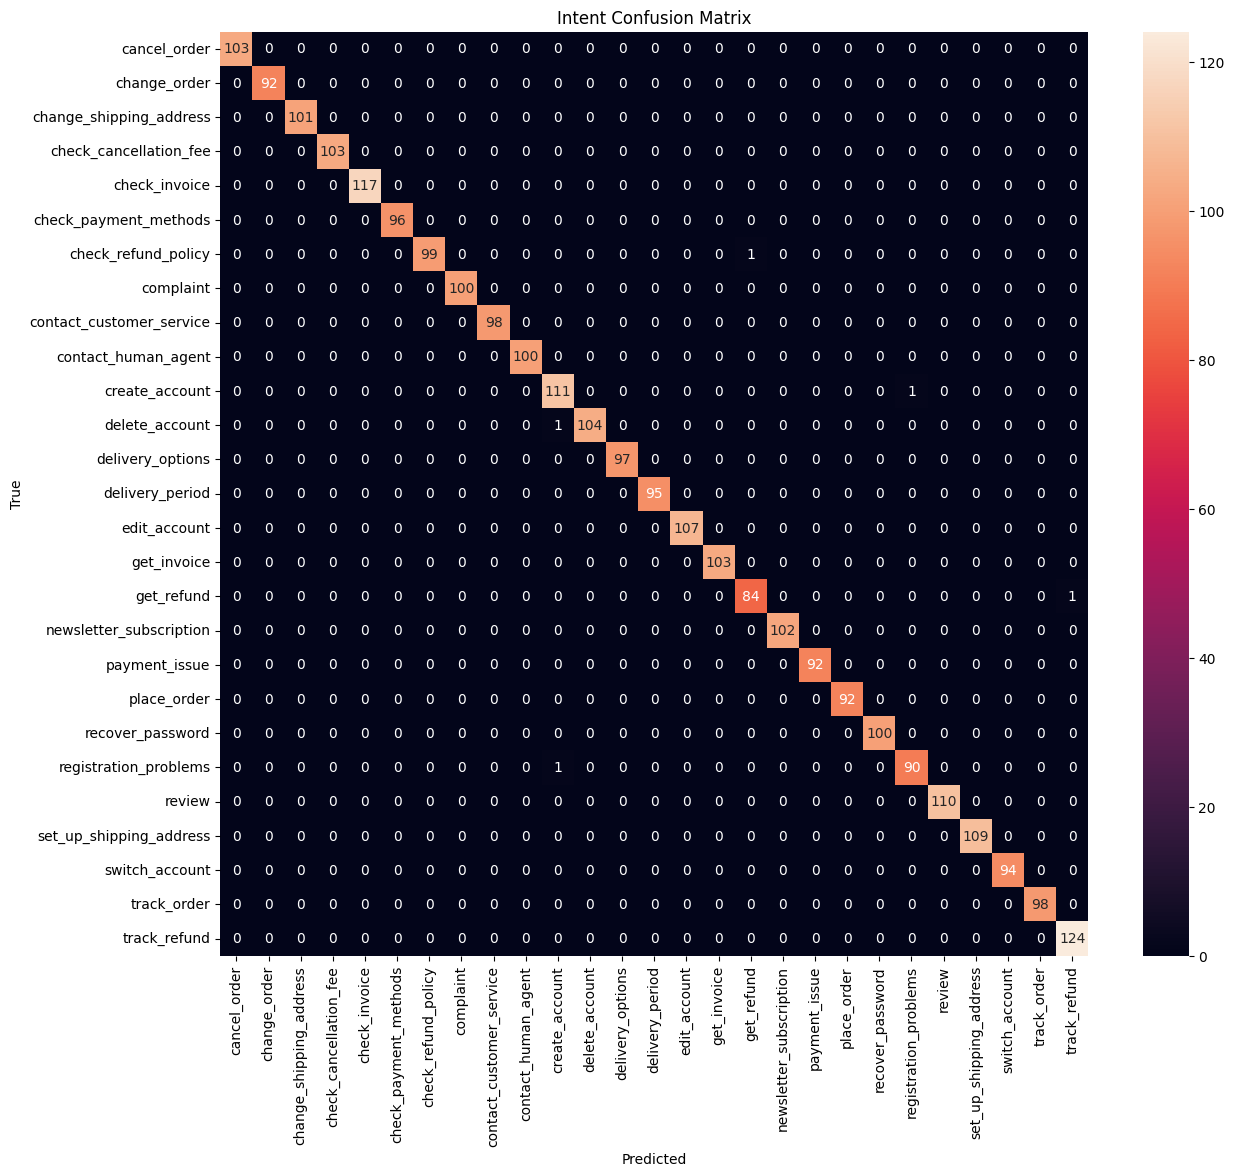

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    results_df["true_intent"],
    results_df["predicted_intent"],
    labels=VALID_INTENTS
)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    xticklabels=VALID_INTENTS,
    yticklabels=VALID_INTENTS,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Intent Confusion Matrix")
plt.show()

In [ ]:
final_model_path = "./qwen_intent_05b_final"

best_model.save_pretrained(
    final_model_path,
    safe_serialization=True
)

tokenizer.save_pretrained(final_model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./qwen_intent_05b_final/tokenizer_config.json',
 './qwen_intent_05b_final/chat_template.jinja',
 './qwen_intent_05b_final/tokenizer.json')

In [ ]:
import shutil

zip_path = shutil.make_archive(
    "qwen_intent_05b_final",
    "zip",
    final_model_path
)

print(zip_path)

/content/qwen_intent_05b_final.zip


In [ ]:
import os

print(os.path.getsize("qwen_intent_05b_final.zip") / (1024**3))

1.7077512247487903


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    "qwen_intent_05b_final.zip",
    "/content/drive/MyDrive/Start_LLM/AI_Customer_Support_Automation_Agent/qwen_intent_05b_final.zip"
)

'/content/drive/MyDrive/Start_LLM/AI_Customer_Support_Automation_Agent/qwen_intent_05b_final.zip'

In [ ]:
import os

path = "/content/drive/MyDrive/qwen_intent_05b_final.zip"

print("Exists:", os.path.exists(path))
print("Size (GB):", os.path.getsize(path) / (1024**3))

Exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/qwen_intent_05b_final.zip'

respose part

In [ ]:
print(dataset)
print(dataset.column_names)

#dataset[["customer_message", "intent", "response"]].head(10)

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})
{'train': ['flags', 'instruction', 'category', 'intent', 'response']}


In [ ]:
print(dataset["train"][0])

{'flags': 'B', 'instruction': 'question about cancelling order {{Order Number}}', 'category': 'ORDER', 'intent': 'cancel_order', 'response': "I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."}


In [ ]:
response_lengths = dataset["train"].map(
    lambda x: {"length": len(x["response"].split())}
)["length"]

print(response_lengths)

Map:   0%|          | 0/26872 [00:00<?, ? examples/s]

Column([37, 48, 205, 166, 191])


In [ ]:
import numpy as np

response_lengths = np.array([
    len(x.split())
    for x in dataset["train"]["response"]
])

print(
    pd.Series(response_lengths).describe(
        percentiles=[.50, .90, .95, .99, .999]
    )
)

count    26872.000000
mean       104.789037
std         52.966204
min          9.000000
50%         90.000000
90%        173.000000
95%        206.000000
99%        300.000000
99.9%      357.129000
max        402.000000
dtype: float64


In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
sample = dataset["train"][0]

text = f"""Customer: {sample["instruction"]}
Intent: {sample["intent"]}
Response: {sample["response"]}"""

tokens = tokenizer(
    text,
    add_special_tokens=True
)

print("Number of tokens:", len(tokens["input_ids"]))

Number of tokens: 63


In [ ]:
response_token_lengths = []

for sample in dataset["train"]:
    text = f"""Customer: {sample["instruction"]}
Intent: {sample["intent"]}
Response: {sample["response"]}"""

    tokens = tokenizer(
        text,
        add_special_tokens=True
    )

    response_token_lengths.append(len(tokens["input_ids"]))


pd.Series(response_token_lengths).describe(
    percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
)

,0
count,26872.000000
mean,145.387727
std,66.605416
min,30.000000
50%,124.000000
90%,234.000000
95%,276.000000
99%,381.000000
99.9%,445.000000
max,501.000000


In [ ]:
sample = dataset["train"][0]

customer = sample["instruction"]
response = sample["response"]

prompt = f"""Customer: {customer}
Response:"""

print("PROMPT:")
print(prompt)

print("\nTARGET:")
print(response)

PROMPT:
Customer: question about cancelling order {{Order Number}}
Response:

TARGET:
I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.


In [ ]:
prompt_tokens = tokenizer(
    prompt,
    add_special_tokens=False
)

response_tokens = tokenizer(
    response,
    add_special_tokens=False
)

print("Prompt tokens:", len(prompt_tokens["input_ids"]))
print("Response tokens:", len(response_tokens["input_ids"]))

Prompt tokens: 12
Response tokens: 46


In [ ]:
def Tokenize_response(row):
  prompt = f"Customer: {row['instruction']}\n response:"
  target = row["response"] + tokenizer.eos_token

  prompt_tokens = tokenizer(
        prompt,
        add_special_tokens=False
    )

  full_tokens = tokenizer(
        prompt + target,
        truncation=True,
        max_length=512,
        add_special_tokens=False
    )

  input_ids = full_tokens["input_ids"]
  attention_mask = full_tokens["attention_mask"]

  prompt_length = len(prompt_tokens["input_ids"])

  labels = [-100] * prompt_length + input_ids[prompt_length:]

  return {
      "input_ids": input_ids,
      "attention_mask": attention_mask,
      "labels": labels
  }



In [ ]:
tokenized_dataset = dataset["train"].map(
    Tokenize_response,
    remove_columns=dataset["train"].column_names
)

In [ ]:
print(tokenized_dataset)
print(tokenized_dataset[0].keys())

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 26872
})
dict_keys(['input_ids', 'attention_mask', 'labels'])


In [ ]:
sample = tokenized_dataset[0]

print("Input length:", len(sample["input_ids"]))
print("Label length:", len(sample["labels"]))

print("Number of target tokens:",
      sum(x != -100 for x in sample["labels"]))

Input length: 58
Label length: 58
Number of target tokens: 46


In [ ]:
target_ids = [
    x for x in sample["labels"]
    if x != -100
]

print(
    tokenizer.decode(
        target_ids,
        skip_special_tokens=True
    )
)

've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)

import pandas as pd

df = dataset["train"].to_pandas()


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

In [ ]:
df_model = df.copy()
df_model = df_model[
    ["instruction", "category", "intent", "response"]
].copy()

df_model = df_model.rename(
    columns={
        "instruction": "customer_message"
    }
)

df_model.head()


,customer_message,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [ ]:
from sklearn.model_selection import train_test_split

unique_instructions = df_model["customer_message"].unique()

train_instructions, temp_instructions = train_test_split(
    unique_instructions,
    test_size=0.20,
    random_state=42
)

val_instructions, test_instructions = train_test_split(
    temp_instructions,
    test_size=0.50,
    random_state=42
)

train_df = df_model[
    df_model["customer_message"].isin(train_instructions)
].copy()

val_df = df_model[
    df_model["customer_message"].isin(val_instructions)
].copy()

test_df = df_model[
    df_model["customer_message"].isin(test_instructions)
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (21482, 4)
Validation: (2663, 4)
Test: (2727, 4)


In [ ]:
from datasets import Dataset

train_intent = train_df[["customer_message", "response"]].copy()
val_intent = val_df[["customer_message", "response"]].copy()
test_intent = test_df[["customer_message", "response"]].copy()

train_intent.head()

,customer_message,response
0,question about cancelling order {{Order Number}},I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",I'm sensitive to the fact that you're facing f...


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_intent,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_intent,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_intent,
    preserve_index=False
)

In [ ]:
test_data = Dataset.from_pandas(
    test_intent,
    preserve_index=False
)

In [ ]:
print(train_dataset)

Dataset({
    features: ['customer_message', 'response'],
    num_rows: 21482
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
import torch
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch.float32
)

model.config.pad_token_id = tokenizer.pad_token_id

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
def Tokenize_response(row):
  prompt = f"Customer: {row['customer_message']}\n Response:"
  target = row["response"] + tokenizer.eos_token

  prompt_tokens = tokenizer(
        prompt,
        add_special_tokens=False
    )

  full_tokens = tokenizer(
        prompt + target,
        truncation=True,
        max_length=512,
        add_special_tokens=False
    )

  input_ids = full_tokens["input_ids"]
  attention_mask = full_tokens["attention_mask"]

  prompt_length = len(prompt_tokens["input_ids"])

  labels = [-100] * prompt_length + input_ids[prompt_length:]

  return {
      "input_ids": input_ids,
      "attention_mask": attention_mask,
      "labels": labels
  }



In [ ]:
train_dataset = train_dataset.map(
    Tokenize_response,
    remove_columns=train_dataset.column_names
)

val_dataset = val_dataset.map(
    Tokenize_response,
    remove_columns=val_dataset.column_names
)

test_dataset = test_dataset.map(
    Tokenize_response,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/21482 [00:00<?, ? examples/s]

Map:   0%|          | 0/2663 [00:00<?, ? examples/s]

Map:   0%|          | 0/2727 [00:00<?, ? examples/s]

In [ ]:
print(test_dataset)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2727
})


In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qwen_response_05b",

    num_train_epochs=2,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,

    fp16=False,

    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.633066,0.633761
2,0.491898,0.592729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=2686, training_loss=0.6082551250329944, metrics={'train_runtime': 9667.5579, 'train_samples_per_second': 4.444, 'train_steps_per_second': 0.278, 'total_flos': 1.2997138653717504e+16, 'train_loss': 0.6082551250329944, 'epoch': 2.0})

In [ ]:
model.save_pretrained("./qwen_response_05b")
tokenizer.save_pretrained("./qwen_response_05b")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./qwen_response_05b/tokenizer_config.json',
 './qwen_response_05b/chat_template.jinja',
 './qwen_response_05b/tokenizer.json')

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

ValueError: mount failed

In [ ]:
import torch

model.eval()
model.to("cuda")

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [ ]:
def generate_response(customer_message):
    prompt = f"""Customer: {customer_message}
Response:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return generated.strip()

In [ ]:
customer_message = "I want to cancel my order."
prompt = f"""Customer: {customer_message}
Response:"""

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

print("Generated token IDs:", generated_tokens)
print("Decoded generated tokens:", tokenizer.decode(generated_tokens, skip_special_tokens=True))

Generated token IDs: tensor([1654, 2299, 1588,  369,  498,  311,  601, 8826,  697, 1681],
       device='cuda:0')
Decoded generated tokens: We're here for you to us regarding your request


In [ ]:
for i in range(10):
    sample = dataset["train"][i]

    customer = sample["instruction"]
    true_response = sample["response"]

    generated_response = generate_response(customer)

    print("=" * 80)
    print("Customer:")
    print(customer)

    print("\nTrue Response:")
    print(true_response)

    print("\nGenerated Response:")
    print(generated_response)

Customer:
question about cancelling order {{Order Number}}

True Response:
I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.

Generated Response:
We're here to help to us with your question regarding canceling order {{Order Number}}. I'm here to assist you every step of the way. Please go ahead and let me know what specific information or clarification you need about canceling this order. Your satisfaction is our top priority, and we want to ensure that all your concerns are addressed.
Customer:
i have a question about cancelling oorder {{Order Number}}

True Response:
I've been informed that you have a question about canceling order {{Order Number}}. I'm here to assist you! Please go ahead and let me know what specific question you have, and I'll provide you with all the information and guidance you need. Your satisfaction i

In [ ]:
import torch

model.eval()
model.to("cuda")

predictions = []
references = []

for sample in test_data:
    customer = sample["customer_message"]
    reference = sample["response"]

    prompt = f"""Customer: {customer}
Response:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=250,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    predictions.append(generated)
    references.append(reference)

print("Number of predictions:", len(predictions))
print("Number of references:", len(references))

KeyboardInterrupt: 

In [ ]:
import random

for i in random.sample(range(len(predictions)), 10):
    print("=" * 100)
    print("Customer:")
    print(test_data[i]["customer_message"])

    print("\nReference:")
    print(references[i])

    print("\nGenerated:")
    print(predictions[i])

Customer:
could you help me canceling purchase {{Order Number}}?

Reference:
Certainly! I understand that you need assistance with canceling your purchase with the order number {{Order Number}}. Rest assured, I'm here to help you navigate through the cancellation process smoothly.

To cancel your purchase, please follow these steps:

1. Sign in to Your Account: Access our platform by logging into your {{Online Company Portal Info}}.
2. Go to Your Orders: Once you're signed in, locate the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.
3. Find Your Purchase: Look for the purchase associated with the order number {{Order Number}} and click on it to view the details.
4. Initiate the Cancellation: Within the order details, you should see an option labeled '{{Online Order Interaction}}'. Please select this option to initiate the cancellation.
5. Confirm Cancellation: The system may ask you to confirm your cancellation. Please follow the prompts to complete the proc

In [ ]:
import torch

model.eval()
model.to("cuda")

predictions = []
references = []

for i, sample in enumerate(test_data):

    customer = sample["customer_message"]
    reference = sample["response"]

    prompt = f"""Customer: {customer}
Response:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=400,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    predictions.append(generated)
    references.append(reference)

    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(test_data)}")

100/2727
200/2727
300/2727
400/2727
500/2727
600/2727


KeyboardInterrupt: 

In [ ]:
print(len(predictions))
print(len(references))

669
669


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
!pip install -q evaluate rouge_score bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.1 MB/s eta 0:00:00


In [ ]:
import evaluate

rouge = evaluate.load("rouge")

rouge_results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True
)

print(rouge_results)

{'rouge1': np.float64(0.6041192464884229), 'rouge2': np.float64(0.34875077352703016), 'rougeL': np.float64(0.45808985802367785), 'rougeLsum': np.float64(0.5014171930006144)}


In [ ]:
bertscore = evaluate.load("bertscore")

bert_results = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en",
    rescale_with_baseline=True
)

print("BERTScore Precision:",
      sum(bert_results["precision"]) / len(bert_results["precision"]))

print("BERTScore Recall:",
      sum(bert_results["recall"]) / len(bert_results["recall"]))

print("BERTScore F1:",
      sum(bert_results["f1"]) / len(bert_results["f1"]))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore Precision: 0.5436737468495397
BERTScore Recall: 0.5427763716417815
BERTScore F1: 0.5431529453027052


**Final Pipline**

In [ ]:
CRITICAL_INTENTS = {
    "payment_issue",
    "complaint",
}

Intent Prediction

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Start_LLM/AI_Customer_Support_Automation_Agent/qwen_intent_05b_final.zip"
extract_path = "/content/qwen_intent_05b"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))



In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

intent_model = AutoModelForCausalLM.from_pretrained(
    extract_path,
    torch_dtype=torch.float16
)

intent_tokenizer = AutoTokenizer.from_pretrained(
    extract_path
)

intent_model.to("cuda")
intent_model.eval()

In [ ]:
import torch

intent_model.eval()
intent_model.to("cuda")

def predict_intent(customer_message):
    inputs = intent_tokenizer(
        customer_message,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():
        outputs = intent_model(**inputs)

    predicted_id = outputs.logits.argmax(dim=-1).item()

    return intent_id2label[predicted_id]

Response Generation

In [ ]:
response_model.eval()
response_model.to("cuda")

def generate_response(customer_message, predicted_intent):

    prompt = f"""Customer: {customer_message}
Intent: {predicted_intent}
Response:"""

    inputs = response_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():
        outputs = response_model.generate(
            **inputs,
            max_new_tokens=400,
            do_sample=False,
            eos_token_id=response_tokenizer.eos_token_id,
            pad_token_id=response_tokenizer.pad_token_id
        )

    generated = response_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return generated.strip()

Copilot

In [ ]:
def customer_support_copilot(customer_message):

    predicted_intent = predict_intent(customer_message)

    if predicted_intent in CRITICAL_INTENTS:
        return {
            "intent": predicted_intent,
            "action": "ESCALATE_TO_HUMAN",
            "response": None
        }

    response = generate_response(
        customer_message,
        predicted_intent
    )

    return {
        "intent": predicted_intent,
        "action": "GENERATE_RESPONSE",
        "response": response
    }